In [2]:
import numpy as np
import sisl
import matplotlib.pyplot  as plt
from mytools.construct import all_armchair
from mytools.scaling import map_index


In [3]:
N1 = 6
N2 = 12

BOND = 1.42
R = (0.1, BOND + 1e-2)
T = (0.0, -2.7)

ETA = 1e-3
NUMK = 300

In [4]:
base = all_armchair(BOND)
Ham0 = sisl.Hamiltonian(base)
Ham0.construct([R, T])

rse1 = sisl.RealSpaceSE(Ham0, 0 , 1, (N1, N1, 1))
rse1.setup(eta=ETA,
           bz=sisl.MonkhorstPack(Ham0, [1, NUMK, 1]))
ElecHam1, elec1 = rse1.real_space_coupling(ret_indices=True)
Ham1 = rse1.real_space_parent()
rse2 = sisl.RealSpaceSE(Ham0, 0 , 1, (N2, N2, 1))
rse2.setup(eta=ETA,
           bz=sisl.MonkhorstPack(Ham0, [1, NUMK, 1]))
ElecHam2, elec2 = rse2.real_space_coupling(ret_indices=True)
Ham2 = rse2.real_space_parent()
rse_gt = sisl.RealSpaceSE(Ham0, 0, 1, (N2, N2, 0))
rse_gt.setup(eta=ETA,
             bz=sisl.MonkhorstPack(Ham0, [1, NUMK, 1]))


In [5]:
g1_to_g2 = map_index(ElecHam1, ElecHam2)

all_atoms1 = np.arange(Ham1.na)
device1 = np.delete(all_atoms1, elec1)
alist1 = np.concat([elec1, device1])

all_atoms2 = np.arange(Ham2.na)
device2 = np.delete(all_atoms2, elec2)
alist2 = np.concat([elec2, device2])

Z = 0 + ETA*1j

RSE1 = rse1.self_energy(Z)
RSE_gt = rse2.self_energy(Z)

<Axes: >

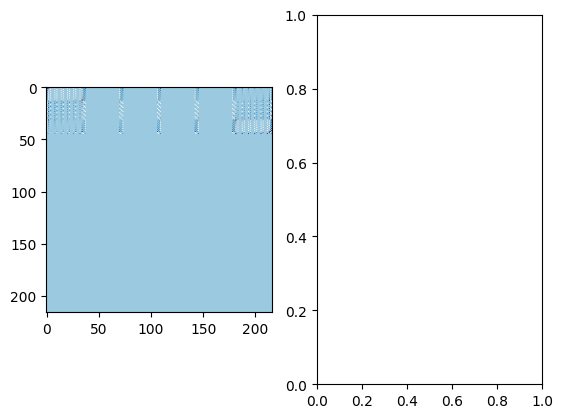

In [6]:
fig, ax = plt.subplots(1, 2)

ax[0].imshow(RSE1[np.ix_(alist1)].imag, cmap="RdBu")
ax[1]
